## Q9 - Image Sharpening


### 1 - Import Required Libraries


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


### 2 - Set Input and Output Paths


In [2]:
img_path = Path("../data/raw/emma.jpg")   # change if needed
out_dir = Path("../results/q09")
out_dir.mkdir(parents=True, exist_ok=True)

print("Input path:", img_path.resolve())
print("Output folder:", out_dir.resolve())


Input path: D:\MSc in AI\1YQ3\CV\Assignment_1\data\raw\emma.jpg
Output folder: D:\MSc in AI\1YQ3\CV\Assignment_1\results\q09


### 3 - Load Image

In [3]:
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)

if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image loaded successfully")
print("Shape:", img_rgb.shape)
print("Data type:", img_rgb.dtype)


Image loaded successfully
Shape: (810, 720, 3)
Data type: uint8


### 4 - Display Original Image

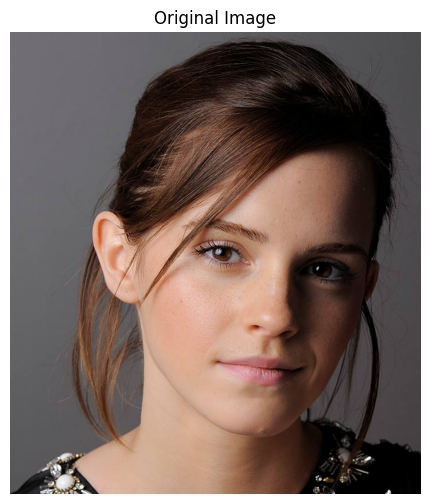

In [4]:
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


### 5 - Define Unsharp Mask Function

In [5]:
def unsharp_mask(img, kernel_size=(5, 5), sigma=1.0, amount=1.5):
    """
    Apply image sharpening using unsharp masking.
    """
    blurred = cv2.GaussianBlur(img, kernel_size, sigmaX=sigma, sigmaY=sigma)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    return blurred, sharpened


### 6 - Apply Image Sharpening

In [6]:
blurred_rgb, sharpened_rgb = unsharp_mask(img_rgb, kernel_size=(5, 5), sigma=1.0, amount=1.5)
print("Image sharpening completed.")


Image sharpening completed.


### 7 - Display Sharpening Results

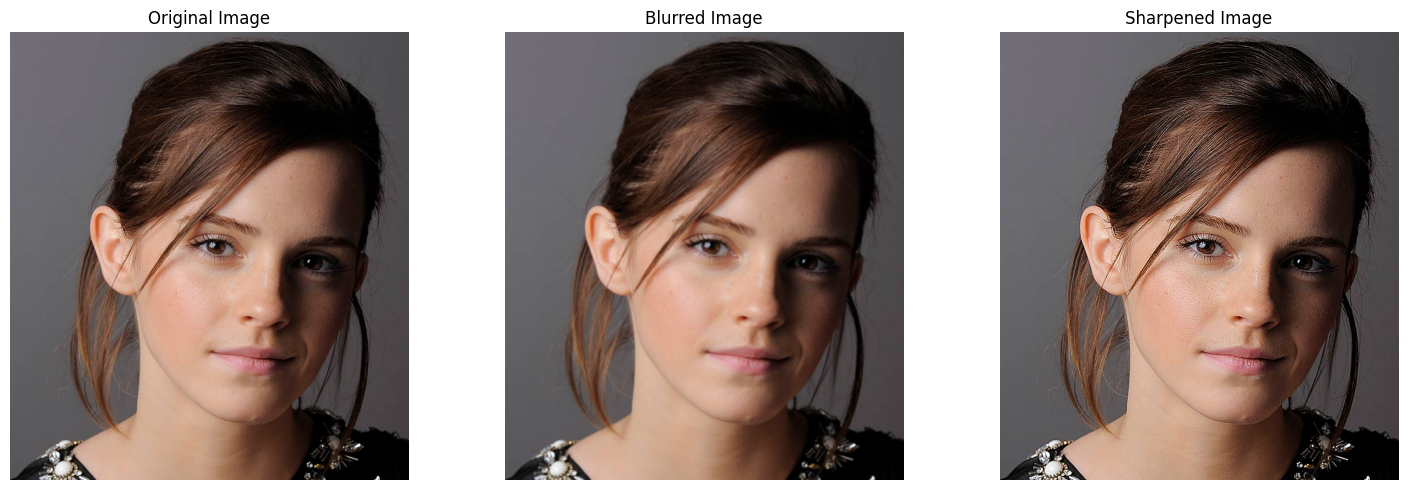

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred_rgb)
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened_rgb)
plt.title("Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.show()


### 8 - Save Output Images

In [8]:
cv2.imwrite(str(out_dir / "q09_original.png"), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(out_dir / "q09_blurred.png"), cv2.cvtColor(blurred_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(out_dir / "q09_sharpened.png"), cv2.cvtColor(sharpened_rgb, cv2.COLOR_RGB2BGR))

print(f"Saved original image to: {out_dir / 'q09_original.png'}")
print(f"Saved blurred image to: {out_dir / 'q09_blurred.png'}")
print(f"Saved sharpened image to: {out_dir / 'q09_sharpened.png'}")


Saved original image to: ..\results\q09\q09_original.png
Saved blurred image to: ..\results\q09\q09_blurred.png
Saved sharpened image to: ..\results\q09\q09_sharpened.png


## Interpretation and Discussion

Image sharpening was carried out using unsharp masking. In this method, a blurred version of the image is first created using Gaussian smoothing. The blurred image is then subtracted from the original image to extract fine detail information, and this detail is added back to the original image.

The sharpened result shows clearer edges and enhanced fine structures compared to the original image. Facial features, hair boundaries, and other image details become more distinct. However, excessive sharpening can create unnatural edges or amplify noise, so the sharpening strength must be chosen carefully.
